In [23]:
import pandas as pd
import numpy as np

In [24]:
df = pd.read_excel("C:\\Users\\21655\\Downloads\\projet modelisation\\base_final.xlsx")
df

,CRD_imputed,PNU_imputed,nb_pret_imputed,Maturite_imputed,Garantie_imputed,flag_lombard_decouvert_clean_imputed,DPD_12M_imputed,Pays_domiciliation_Autres,Etat_civil_Celibataire,Etat_civil_Divorce,...,Segment_clean_Retail_GOLD,Segment_clean_Private_customer,Age_relation_imputed,Solde_moyen_imputed,Revenus_mensuels_imputed,Solde_arrete_imputed,Engagement_imputed,CRD/gar_clean_imputed,CRD_eng_clean_imputed,flag_default
0,3877.51,54792.50,1,15,109585.0,1,0,1,0,0,...,1,0,35,16512.975,27000.0,-3877.510000,54792.50,0.035384,0.070767,0
1,8087.98,45936.25,1,15,0.0,1,0,1,0,0,...,1,0,35,16512.975,27000.0,-8115.410000,45936.25,0.934189,0.176070,0
2,11702.36,45000.00,1,15,0.0,1,0,1,0,0,...,1,0,35,16512.975,27000.0,-8115.410000,45000.00,0.934189,0.260052,0
3,328.53,53085.75,1,15,0.0,1,0,1,0,0,...,1,0,35,16512.975,27000.0,-328.530000,53085.75,0.934189,0.006189,0
4,1277030.69,0.00,1,18,2475000.0,0,0,0,0,0,...,0,1,35,16512.975,27000.0,78611.768604,2650000.00,0.515972,0.481898,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5720,11446146.41,2197887.49,10,11,6000000.0,0,0,0,0,0,...,0,1,35,16512.975,27000.0,180283.456160,14520146.41,1.907691,0.788294,0
5721,54456.83,0.00,2,4,0.0,0,0,0,0,1,...,0,0,35,6250.910,25000.0,5987.165212,80000.00,0.934189,0.680710,0
5722,38715.65,0.00,2,3,0.0,0,0,0,0,1,...,0,0,35,10014.360,25000.0,3910.234433,80000.00,0.934189,0.483946,0
5723,21574.63,0.00,2,2,0.0,0,0,0,0,1,...,0,0,35,9857.360,25000.0,3909.298883,80000.00,0.934189,0.269683,0


In [25]:
df.head()
df.shape
df.isnull().sum()

CRD_imputed                                                   0
PNU_imputed                                                   0
nb_pret_imputed                                               0
Maturite_imputed                                              0
Garantie_imputed                                              0
flag_lombard_decouvert_clean_imputed                          0
DPD_12M_imputed                                               0
Pays_domiciliation_Autres                                     0
Etat_civil_Celibataire                                        0
Etat_civil_Divorce                                            0
Etat_civil_Veuf                                               0
Nationalite_Morocco                                           0
Profession_CHEF_D'ENTREPRISE                                  0
Profession_DIRECTEUR                                          0
Segmentation_commerciale_Revenus salariés_S5                  0
Segmentation_commerciale_Revenus salarié

In [26]:
df["CRD_eng_clean_imputed"].isnull().sum()

5

In [27]:
median_crd_eng = df["CRD_eng_clean_imputed"].median()
median_crd_eng

0.9807396940941084

In [28]:
df["CRD_eng_clean_imputed"] = df["CRD_eng_clean_imputed"].fillna(median_crd_eng)

In [29]:
df.isnull().sum()

CRD_imputed                                                   0
PNU_imputed                                                   0
nb_pret_imputed                                               0
Maturite_imputed                                              0
Garantie_imputed                                              0
flag_lombard_decouvert_clean_imputed                          0
DPD_12M_imputed                                               0
Pays_domiciliation_Autres                                     0
Etat_civil_Celibataire                                        0
Etat_civil_Divorce                                            0
Etat_civil_Veuf                                               0
Nationalite_Morocco                                           0
Profession_CHEF_D'ENTREPRISE                                  0
Profession_DIRECTEUR                                          0
Segmentation_commerciale_Revenus salariés_S5                  0
Segmentation_commerciale_Revenus salarié

In [30]:
df.to_excel("base_final_corrige.xlsx", index=False)

In [31]:
#Séparation Train / Test (70 % / 30 %)
df = pd.read_excel("base_final_corrige.xlsx")
df.shape
df["flag_default"].value_counts()

flag_default
0    5608
1     117
Name: count, dtype: int64

In [32]:
X = df.drop("flag_default", axis=1)
y = df["flag_default"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [34]:
#Taille des échantillons
X_train.shape, X_test.shape

((4007, 36), (1718, 36))

In [35]:
#Distribution de la cible
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

flag_default
0    0.979627
1    0.020373
Name: proportion, dtype: float64

In [36]:
#Rééchantillonnage pour équilibrer les données(SMOTE)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote.value_counts()

flag_default
0    3925
1    3925
Name: count, dtype: int64

In [37]:
y_train_smote.value_counts(normalize=True)

flag_default
0    0.5
1    0.5
Name: proportion, dtype: float64

In [38]:
y_test.value_counts(normalize=True)

flag_default
0    0.979627
1    0.020373
Name: proportion, dtype: float64

In [39]:
#Sélection des variables par l’Information Value (IV)
!pip install scorecardpy

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60661 sha256=6daf03d9be8e7f3cf0b76df56017a1bfe52d1d95b42fddaee15b552f0dc84356
  Stored in directory: c:\users\21655\appdata\local\pip\cache\wheels\9f\d8\4e\61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


In [40]:
import scorecardpy as sc
import pandas as pd
train_smote = pd.concat(
    [X_train_smote, y_train_smote], axis=1
)
train_smote.head()

,CRD_imputed,PNU_imputed,nb_pret_imputed,Maturite_imputed,Garantie_imputed,flag_lombard_decouvert_clean_imputed,DPD_12M_imputed,Pays_domiciliation_Autres,Etat_civil_Celibataire,Etat_civil_Divorce,...,Segment_clean_Retail_GOLD,Segment_clean_Private_customer,Age_relation_imputed,Solde_moyen_imputed,Revenus_mensuels_imputed,Solde_arrete_imputed,Engagement_imputed,CRD/gar_clean_imputed,CRD_eng_clean_imputed,flag_default
0,2333221.31,0.00,1,11,2382932.0,0,0,0,0,0,...,0,1,35,128215.38,23589.98,30011.340000,2382932.00,0.979139,0.979139,0
1,1748349.34,0.00,2,15,1500000.0,0,0,0,0,0,...,0,0,62,69753.29,27000.00,161939.114568,1761507.88,1.165566,0.992530,0
2,1306029.65,0.00,1,6,2200000.0,0,0,0,0,0,...,0,0,94,-12656.30,20513.00,86213.938116,1306029.65,0.593650,1.000000,0
3,2754696.07,618.83,2,10,3300000.0,1,0,0,0,0,...,0,0,38,8521.50,25000.00,8972.163714,3310000.00,0.834756,0.832234,0
4,873770.56,0.00,1,13,990000.0,0,0,0,0,0,...,1,0,31,5142.64,8000.00,653.314919,990000.00,0.882597,0.882597,0


In [41]:
#Calculer l’IV de toutes les variables
iv_df = sc.iv(
    train_smote,
    y="flag_default"
)
iv_df.sort_values(by="info_value", ascending=False)

,variable,info_value
11,DPD_12M_imputed,7.836735
26,Revenus_mensuels_imputed,0.790518
20,Garantie_imputed,0.741518
32,Maturite_imputed,0.706538
19,Engagement_imputed,0.608042
4,Age_relation_imputed,0.568190
30,CRD_eng_clean_imputed,0.446890
23,CRD_imputed,0.248495
2,Catégorie_sociale_Cadres_spécialises,0.214736
5,Etat_civil_Celibataire,0.164705


In [42]:
#Sélection des variables pertinentes
variables_retenues = iv_df[iv_df["info_value"] >= 0.02]["variable"].tolist()
variables_retenues

['DPD_12M_imputed',
 'Revenus_mensuels_imputed',
 'Garantie_imputed',
 'Maturite_imputed',
 'Engagement_imputed',
 'Age_relation_imputed',
 'CRD_eng_clean_imputed',
 'CRD_imputed',
 'Catégorie_sociale_Cadres_spécialises',
 'Etat_civil_Celibataire',
 'Segment_clean_Retail_GOLD',
 'Solde_arrete_imputed',
 'Segmentation_commerciale_Revenus salariés_S3',
 'Nationalite_Morocco',
 'Segment_clean_Retail_SILVER',
 'nb_pret_imputed',
 'CRD/gar_clean_imputed',
 'Segmentation_commerciale_Revenus salariés_S5',
 'Catégorie_sociale_Directeurs',
 'PNU_imputed',
 'Catégorie_sociale_Cadres_administratifs_moyens',
 'Solde_moyen_imputed',
 'Catégorie_sociale_Autre',
 'Interdiction_cheque_clean_imputed',
 "Profession_CHEF_D'ENTREPRISE",
 'Profession_DIRECTEUR']

In [43]:
X_train_iv = X_train_smote[variables_retenues]
X_test_iv = X_test[variables_retenues]

In [44]:
variables_finales = [
    v for v in variables_retenues if v != "DPD_12M_imputed"
]

In [68]:
X_train_iv = X_train_smote[variables_finales]
X_test_iv = X_test[variables_finales]

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X_train_iv.corr()


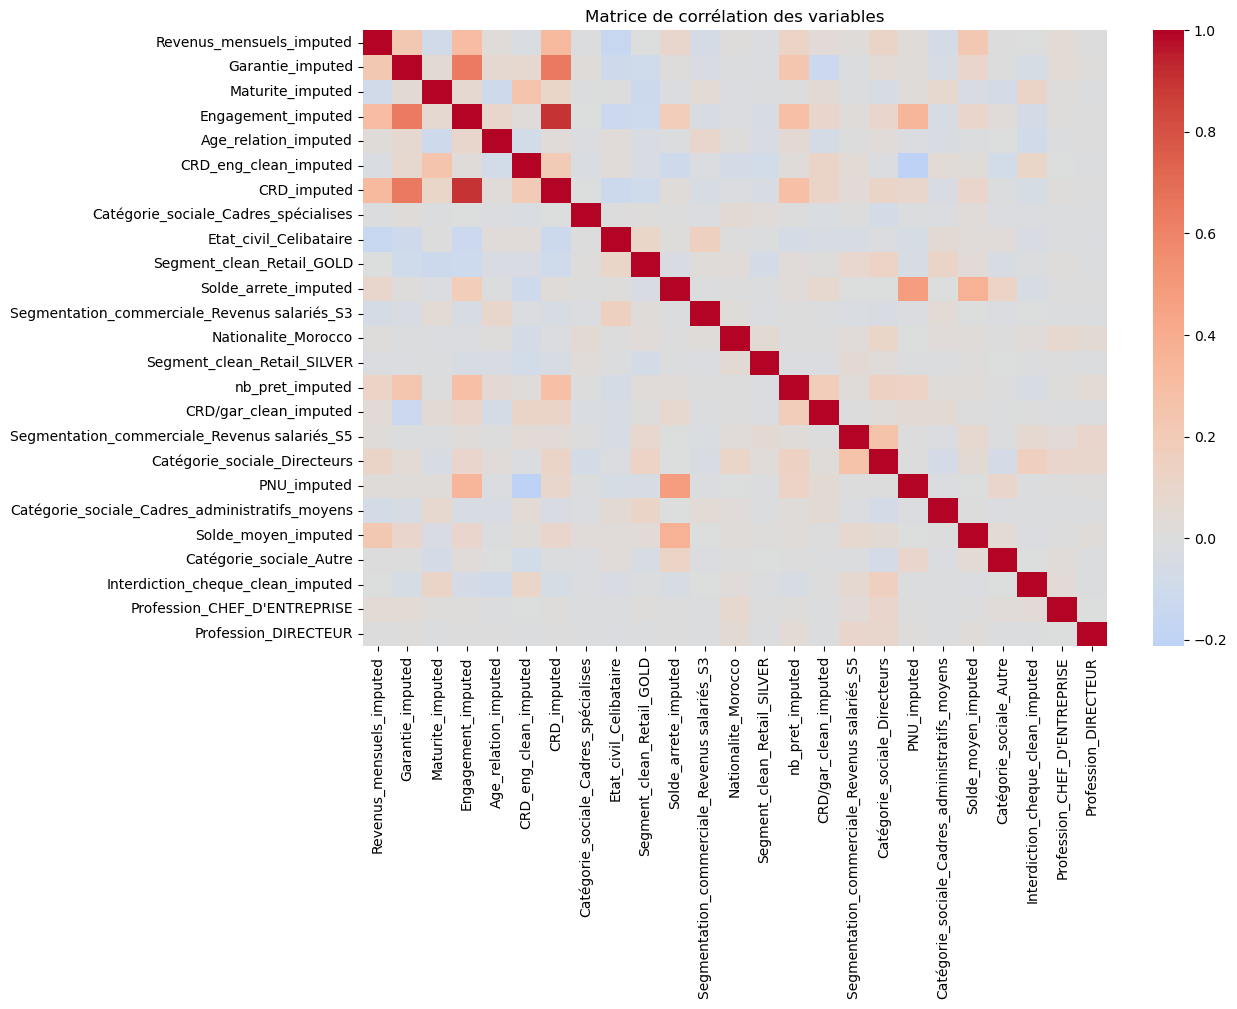

In [72]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables")
plt.show()


In [78]:
# Sélection finale des variables
# Basée sur :
# - Information Value (IV >= 0.02)
# - Analyse de corrélation pour éviter la multicolinéarité
# - Conservation de la variable la plus pertinente (IV + sens métier)


In [99]:
variables_finales = [
    "Engagement_imputed",
    "Revenus_mensuels_imputed",
    "Garantie_imputed",
    "Maturite_imputed",
    "Age_relation_imputed",
    "Interdiction_cheque_clean_imputed",
    "Etat_civil_Celibataire",
    "Nationalite_Morocco"
]


In [101]:
data = df

X = data[variables_finales]
y = data["flag_default"]

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [107]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [109]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

logit.fit(X_train_smote, y_train_smote)


LogisticRegression(max_iter=1000)

In [111]:
y_pred_proba = logit.predict_proba(X_test)[:, 1]
y_pred = logit.predict(X_test)

In [113]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * auc - 1

auc, gini


(0.6139886257533316, 0.22797725150666315)

In [115]:
import pandas as pd

coef_df = pd.DataFrame({
    "Variable": X_train_smote.columns,
    "Coefficient": logit.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coef_df


,Variable,Coefficient
4,Age_relation_imputed,1.446800e-02
5,Interdiction_cheque_clean_imputed,7.662151e-04
0,Engagement_imputed,1.044374e-07
2,Garantie_imputed,-6.190719e-08
1,Revenus_mensuels_imputed,-1.363093e-06
7,Nationalite_Morocco,-6.629437e-04
6,Etat_civil_Celibataire,-4.100085e-03
3,Maturite_imputed,-4.755210e-02


In [ ]:
#Le modèle met en évidence que le risque de défaut est principalement expliqué par l’ancienneté de la relation, le niveau d’engagement et la présence d’incidents bancaires.
#À l’inverse, des revenus plus élevés, des garanties et certaines caractéristiques socio‑démographiques réduisent la probabilité de défaut.

In [117]:
# Prédiction de la PD
pd_test = logit.predict_proba(X_test)[:, 1]

# Ajout dans un DataFrame
resultats = X_test.copy()
resultats["PD"] = pd_test
resultats["flag_default"] = y_test.values

resultats.head()


,Engagement_imputed,Revenus_mensuels_imputed,Garantie_imputed,Maturite_imputed,Age_relation_imputed,Interdiction_cheque_clean_imputed,Etat_civil_Celibataire,Nationalite_Morocco,PD,flag_default
1020,2500000.00,27000.0,2500000.0,17,53,0,0,0,0.506974,0
4363,1292690.00,25000.0,1292690.0,14,35,0,0,0,0.465433,0
4715,1590226.49,43572.0,1680000.0,19,23,0,0,0,0.361679,0
2916,650000.00,27000.0,650000.0,18,35,0,0,0,0.411260,0
2050,417000.00,7000.0,417000.0,20,40,0,1,0,0.408959,0


In [119]:
def classe_risque(pd):
    if pd < 0.2:
        return "Faible risque"
    elif pd < 0.4:
        return "Risque moyen"
    else:
        return "Risque élevé"

resultats["Classe_risque"] = resultats["PD"].apply(classe_risque)

resultats[["PD", "Classe_risque", "flag_default"]].head()


,PD,Classe_risque,flag_default
1020,0.506974,Risque élevé,0
4363,0.465433,Risque élevé,0
4715,0.361679,Risque moyen,0
2916,0.411260,Risque élevé,0
2050,0.408959,Risque élevé,0


In [121]:
resultats["Classe_risque"].value_counts(normalize=True)


Classe_risque
Risque élevé     0.840512
Risque moyen     0.156577
Faible risque    0.002910
Name: proportion, dtype: float64

In [ ]:
#La majorité des clients est classée en risque élevé.
#Cette distribution s’explique par le déséquilibre initial de la variable cible et par l’utilisation du rééchantillonnage SMOTE, qui renforce la capacité du modèle à détecter les profils risqués. 

In [125]:
# Création d’un score simple à partir de la PD
resultats["Score"] = 850 - (resultats["PD"] * 550)

resultats[["PD", "Score", "Classe_risque"]].head()



,PD,Score,Classe_risque
1020,0.506974,571.164189,Risque élevé
4363,0.465433,594.012014,Risque élevé
4715,0.361679,651.076696,Risque moyen
2916,0.411260,623.806921,Risque élevé
2050,0.408959,625.072540,Risque élevé


In [129]:
#Les probabilités de défaut ont été transformées en un score crédit compris entre 300 et 850, afin de faciliter l’interprétation et le classement des clients. Un score faible correspond à un risque de défaut élevé, tandis qu’un score élevé indique un profil plus sûr.

In [131]:
df_model = df[variables_finales + ["flag_default"]]
df_model.to_excel("base_modelisation.xlsx", index=False)

In [135]:
resultats.to_excel("resultats_scoring.xlsx", index=False)


In [137]:
iv_df.to_excel("iv_variables.xlsx", index=False)